# Milestone 2: Insurance Price Prediction - Modeling, Explainability, and Deployment

## 1. Modeling Objective

Milestone 2 builds on the Milestone 1 cleaned dataset and evaluates predictive models for
`insurance_cost`. The final package reports raw regression metrics, quote-band rounding,
calibration behavior, explainability outputs, and Streamlit deployment artifacts.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "Insurance Data.csv").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

TABLE_DIR = ROOT / "outputs" / "tables"
FIG_DIR = ROOT / "outputs" / "figures"
MODEL_DIR = ROOT / "outputs" / "models"

pd.set_option("display.max_columns", 80)

**Technical interpretation:** The modeling notebook reads the same generated artifacts used by the reports and app.

**Business interpretation:** Reviewers can audit final metrics without rerunning every expensive model cell inside the notebook.

## 2. Train/Test Strategy and Target Stratification

In [2]:
split_check = pd.read_csv(TABLE_DIR / "target_band_split_check.csv")
display(split_check.head())
display(split_check.tail())

,insurance_cost,train_count,test_count,train_pct,test_pct
0,2468,10,2,0.050,0.04
1,3702,247,62,1.235,1.24
2,4936,158,39,0.790,0.78
3,6170,776,194,3.880,3.88
4,7404,971,243,4.855,4.86


,insurance_cost,train_count,test_count,train_pct,test_pct
49,62934,70,17,0.350,0.34
50,64168,62,15,0.310,0.30
51,65402,45,11,0.225,0.22
52,66636,22,5,0.110,0.10
53,67870,14,3,0.070,0.06


**Technical interpretation:** The train/test split preserves the target quote-band distribution, reducing evaluation bias from rare bands.

**Business interpretation:** Business quote bands remain represented during model testing, which makes the reported errors more credible.

## 3. Model Families Compared

In [3]:
metrics = pd.read_csv(MODEL_DIR / "model_metrics.csv")
metrics[["model", "cv_rmse_mean", "test_MAE", "test_RMSE", "test_R2", "selected_final_model"]]

,model,cv_rmse_mean,test_MAE,test_RMSE,test_R2,selected_final_model
0,HistGradientBoostingRegressor,2942.5278,2381.4487,2971.1530,0.9568,False
1,WeightedBlendLightGBMEnhancedHGB,2943.4948,2379.2146,2971.5392,0.9568,False
2,WeightedBlendLightGBMBaseHGB,2942.0065,2381.7759,2973.6164,0.9567,False
3,TunedHistGradientBoostingRegressor,2941.9921,2384.8831,2974.4235,0.9567,False
4,LightGBMRegressor,2952.3357,2380.6449,2976.2816,0.9567,False
5,WeightedBlendBaseEnhancedHGB,2940.5779,2385.2706,2977.4584,0.9566,False
6,BaseLightGBMRegressor,2955.2118,2384.1059,2978.0671,0.9566,False
7,BaseHistGradientBoostingRegressor,2947.1901,2387.3391,2980.0395,0.9566,False
8,BaseHistGradientBoostingRegressorAlt,2942.4318,2393.5902,2982.4414,0.9565,True
9,XGBRegressor,2968.5015,2402.1544,2987.1820,0.9564,False


**Technical interpretation:** The comparison includes baseline, linear, regularized, tree, ensemble, boosted, and optional external boosting candidates when installed.

**Business interpretation:** A reviewer can see the final model was chosen from a broad candidate pool, not from a single default algorithm.

## 4. Baseline and Linear Models

In [4]:
metrics[metrics["model"].isin(["DummyRegressor", "LinearRegression", "Ridge", "LogTargetRidge"])][
    ["model", "test_MAE", "test_RMSE", "test_R2"]
]

,model,test_MAE,test_RMSE,test_R2
16,Ridge,2744.8449,3378.9149,0.9442
17,LinearRegression,2745.2974,3379.1483,0.9441
20,LogTargetRidge,4272.1745,6456.3507,0.7961
21,DummyRegressor,11805.0389,14298.5236,-0.0000


**Technical interpretation:** Baseline and linear models provide interpretability but underperform the stronger nonlinear models.

**Business interpretation:** They establish a reasonable performance floor and justify moving to tree-based learners.

## 5. Tree and Boosting Models

In [5]:
tree_metrics = metrics[~metrics["model"].isin(["DummyRegressor", "LinearRegression", "Ridge", "LogTargetRidge"])]
tree_metrics[["model", "test_MAE", "test_RMSE", "test_R2", "train_test_RMSE_gap", "selected_final_model"]]

,model,test_MAE,test_RMSE,test_R2,train_test_RMSE_gap,selected_final_model
0,HistGradientBoostingRegressor,2381.4487,2971.1530,0.9568,216.0094,False
1,WeightedBlendLightGBMEnhancedHGB,2379.2146,2971.5392,0.9568,235.6278,False
2,WeightedBlendLightGBMBaseHGB,2381.7759,2973.6164,0.9567,210.5697,False
3,TunedHistGradientBoostingRegressor,2384.8831,2974.4235,0.9567,175.7993,False
4,LightGBMRegressor,2380.6449,2976.2816,0.9567,303.5343,False
5,WeightedBlendBaseEnhancedHGB,2385.2706,2977.4584,0.9566,160.2912,False
6,BaseLightGBMRegressor,2384.1059,2978.0671,0.9566,278.1514,False
7,BaseHistGradientBoostingRegressor,2387.3391,2980.0395,0.9566,188.3075,False
8,BaseHistGradientBoostingRegressorAlt,2393.5902,2982.4414,0.9565,138.2858,True
9,XGBRegressor,2402.1544,2987.1820,0.9564,210.3580,False


**Model comparison by test RMSE**

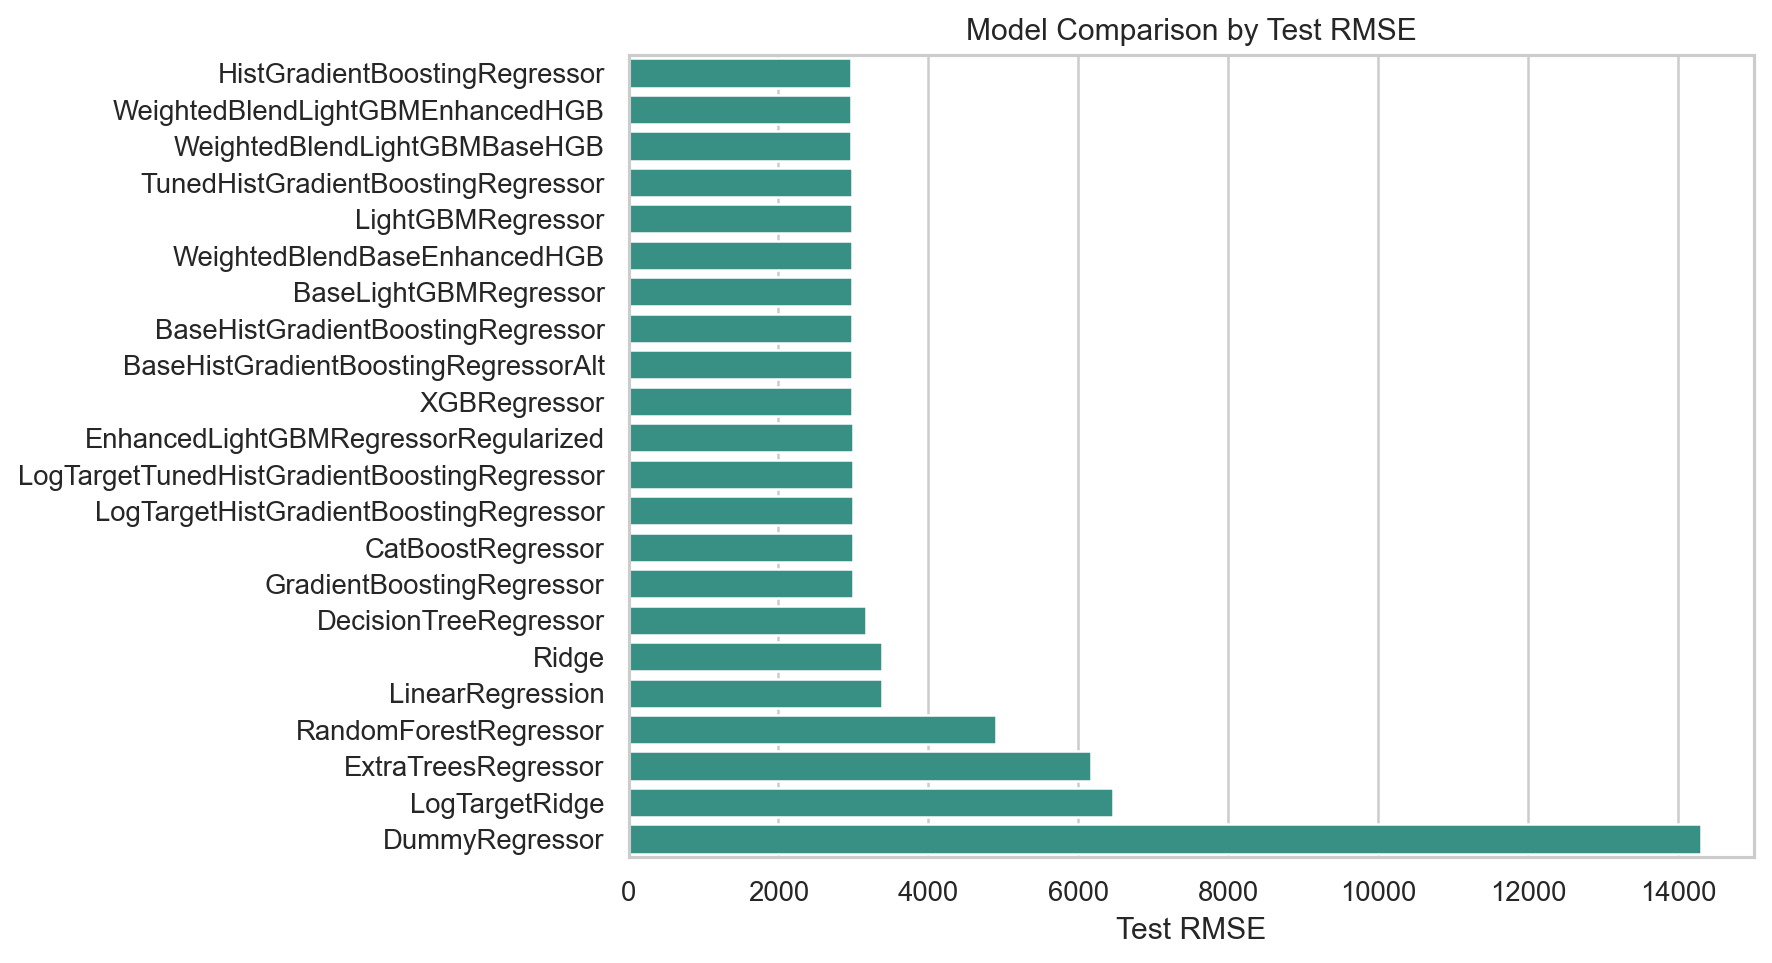

In [6]:
image_path = ROOT / 'outputs/figures/model_comparison_rmse.png'
display(Markdown("**Model comparison by test RMSE**"))
if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print(f"Missing image: {image_path}")

**Technical interpretation:** Histogram gradient boosting variants are near the top of the test-RMSE ranking with modest train-test gaps.

**Business interpretation:** The final selection favors strong performance with simpler deployment behavior rather than only the absolute lowest test RMSE.

## 6. Final Model Selection

In [7]:
metadata = json.loads((MODEL_DIR / "model_metadata.json").read_text())
final_summary = pd.read_csv(MODEL_DIR / "final_model_summary.csv")
display(metadata)
display(final_summary)

{'final_model': 'BaseHistGradientBoostingRegressorAlt',
 'best_params': {},
 'all_tuned_best_params': {'TunedHistGradientBoostingRegressor': {'model__min_samples_leaf': 35,
   'model__max_leaf_nodes': 31,
   'model__max_iter': 360,
   'model__max_bins': 255,
   'model__learning_rate': 0.03,
   'model__l2_regularization': 0.05},
  'LogTargetTunedHistGradientBoostingRegressor': {'regressor__model__min_samples_leaf': 15,
   'regressor__model__max_leaf_nodes': 45,
   'regressor__model__max_iter': 460,
   'regressor__model__max_bins': 255,
   'regressor__model__learning_rate': 0.03,
   'regressor__model__l2_regularization': 0.05}},
 'train_rows': 20000,
 'test_rows': 5000,
 'random_state': 42,
 'split_strategy': 'target-price-band stratified 80/20 split',
 'target_grid': {'target_unique_count': 54,
  'target_grid_step': 1234,
  'target_min': 2468,
  'target_max': 67870,
  'valid_target_levels': [2468,
   3702,
   4936,
   6170,
   7404,
   8638,
   9872,
   11106,
   12340,
   13574,
   148

,selected_model,best_test_model,best_cv_model,selected_test_MAE,selected_test_RMSE,selected_test_R2,best_test_RMSE,best_cv_RMSE,selection_reason
0,BaseHistGradientBoostingRegressorAlt,HistGradientBoostingRegressor,WeightedBlendBaseEnhancedHGB,2393.5902,2982.4414,0.9565,2971.153,2940.5779,Best 5-fold CV RMSE was WeightedBlendBaseEnhan...


**Technical interpretation:** The selected final model is explicitly flagged in `model_metrics.csv` and summarized in `final_model_summary.csv`.

**Business interpretation:** The package explains the model as a parsimony/stability selection, not as an incorrect lowest-test-RMSE claim.

## 7. Repeated Cross-validation

In [8]:
repeated_cv = pd.read_csv(MODEL_DIR / "repeated_cv_metrics.csv")
repeated_cv

,model,repeated_cv_rmse_mean,repeated_cv_rmse_std,repeated_cv_mae_mean,repeated_cv_mae_std,folds,repeats
0,WeightedBlendLightGBMEnhancedHGB,2946.7532,10.8584,2355.8973,13.7077,3,2
1,WeightedBlendLightGBMBaseHGB,2947.0750,10.6434,2356.7455,12.4123,3,2
2,WeightedBlendBaseEnhancedHGB,2948.8930,9.6252,2358.7848,10.6346,3,2
3,TunedHistGradientBoostingRegressor,2951.3843,7.8816,2362.9056,9.0802,3,2
4,BaseHistGradientBoostingRegressorAlt,2953.9308,9.1293,2367.0127,9.2010,3,2
5,HistGradientBoostingRegressor,2954.6054,8.0952,2365.3898,9.9104,3,2
6,LightGBMRegressor,2963.2784,11.0904,2369.0562,13.5816,3,2


**Technical interpretation:** Repeated cross-validation checks whether leading candidates remain competitive across multiple folds.

**Business interpretation:** This gives the final model a stronger stability argument than one train/test split alone.

## 8. Calibration and Price-grid Evaluation

In [9]:
price_grid_eval = pd.read_csv(MODEL_DIR / "price_grid_evaluation.csv")
calibration = pd.read_csv(MODEL_DIR / "calibration_comparison.csv")
display(price_grid_eval)
display(calibration)

,variant,MAE,RMSE,R2,MAPE,SMAPE,exact_band_accuracy,within_1_band_accuracy,within_2_band_accuracy,within_3_band_accuracy
0,raw_continuous,2393.59019,2982.44142,0.95649,11.69329,11.26017,0.1592,0.4606,0.6960,0.8470
1,calibrated_continuous,2404.68276,3009.75577,0.95569,11.63329,11.18286,0.1672,0.4528,0.6908,0.8502
2,rounded_to_nearest_price_band,2379.15200,3007.21521,0.95577,11.64899,11.19377,0.1592,0.4606,0.6960,0.8470
3,calibrated_then_rounded,2389.76440,3030.77032,0.95507,11.65667,11.11256,0.1672,0.4528,0.6908,0.8502


,variant,MAE,RMSE,R2,MAPE,SMAPE,exact_band_accuracy,within_1_band_accuracy,within_2_band_accuracy,within_3_band_accuracy,RMSE_delta_vs_raw,MAE_delta_vs_raw
0,raw_continuous,2393.59019,2982.44142,0.95649,11.69329,11.26017,0.1592,0.4606,0.6960,0.8470,0.00000,0.00000
1,calibrated_continuous,2404.68276,3009.75577,0.95569,11.63329,11.18286,0.1672,0.4528,0.6908,0.8502,27.31435,11.09257
2,rounded_to_nearest_price_band,2379.15200,3007.21521,0.95577,11.64899,11.19377,0.1592,0.4606,0.6960,0.8470,24.77379,-14.43819
3,calibrated_then_rounded,2389.76440,3030.77032,0.95507,11.65667,11.11256,0.1672,0.4528,0.6908,0.8502,48.32890,-3.82579


**Calibration curve**

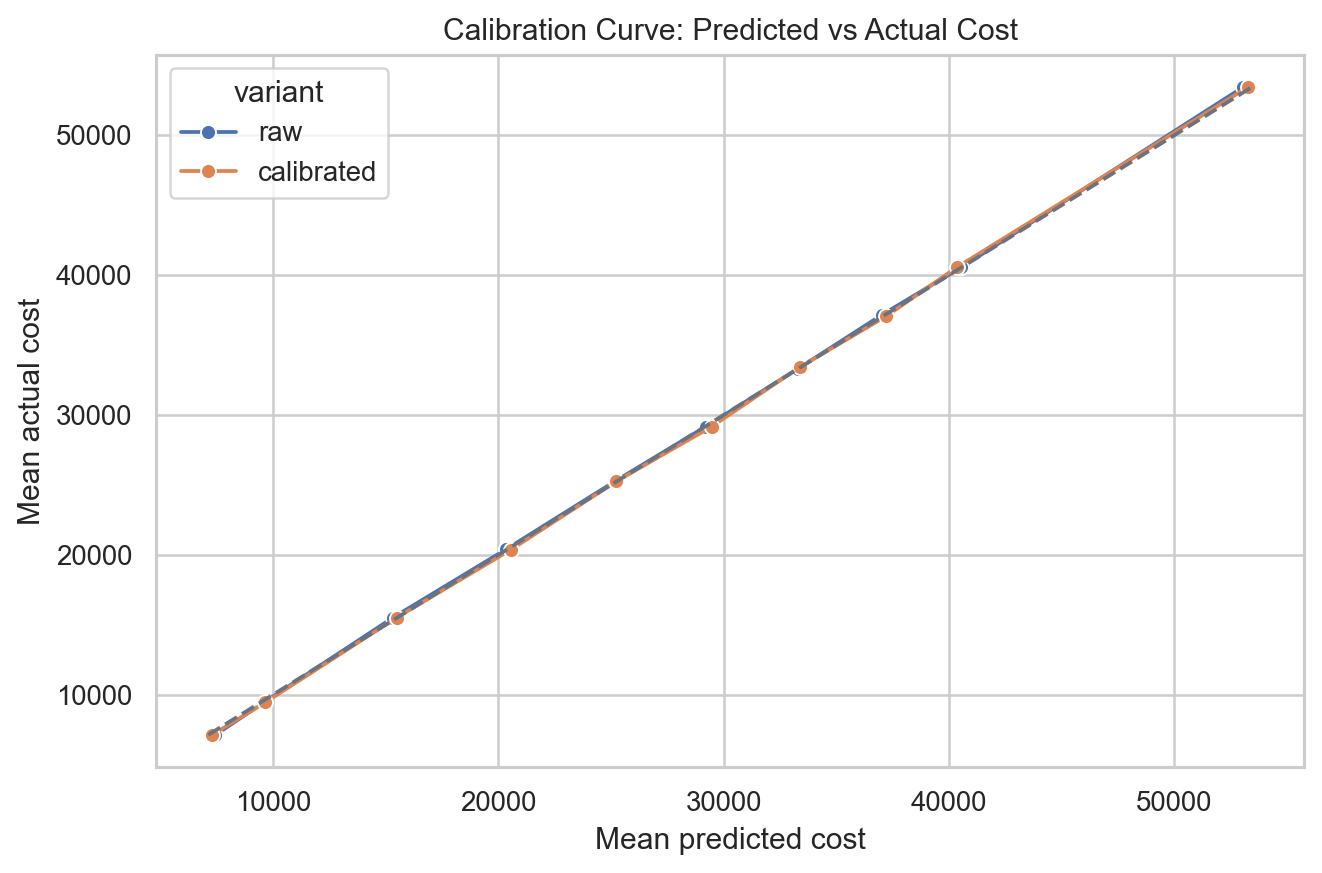

In [10]:
image_path = ROOT / 'outputs/figures/calibration_curve.png'
display(Markdown("**Calibration curve**"))
if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print(f"Missing image: {image_path}")

**Residuals by cost decile after calibration**

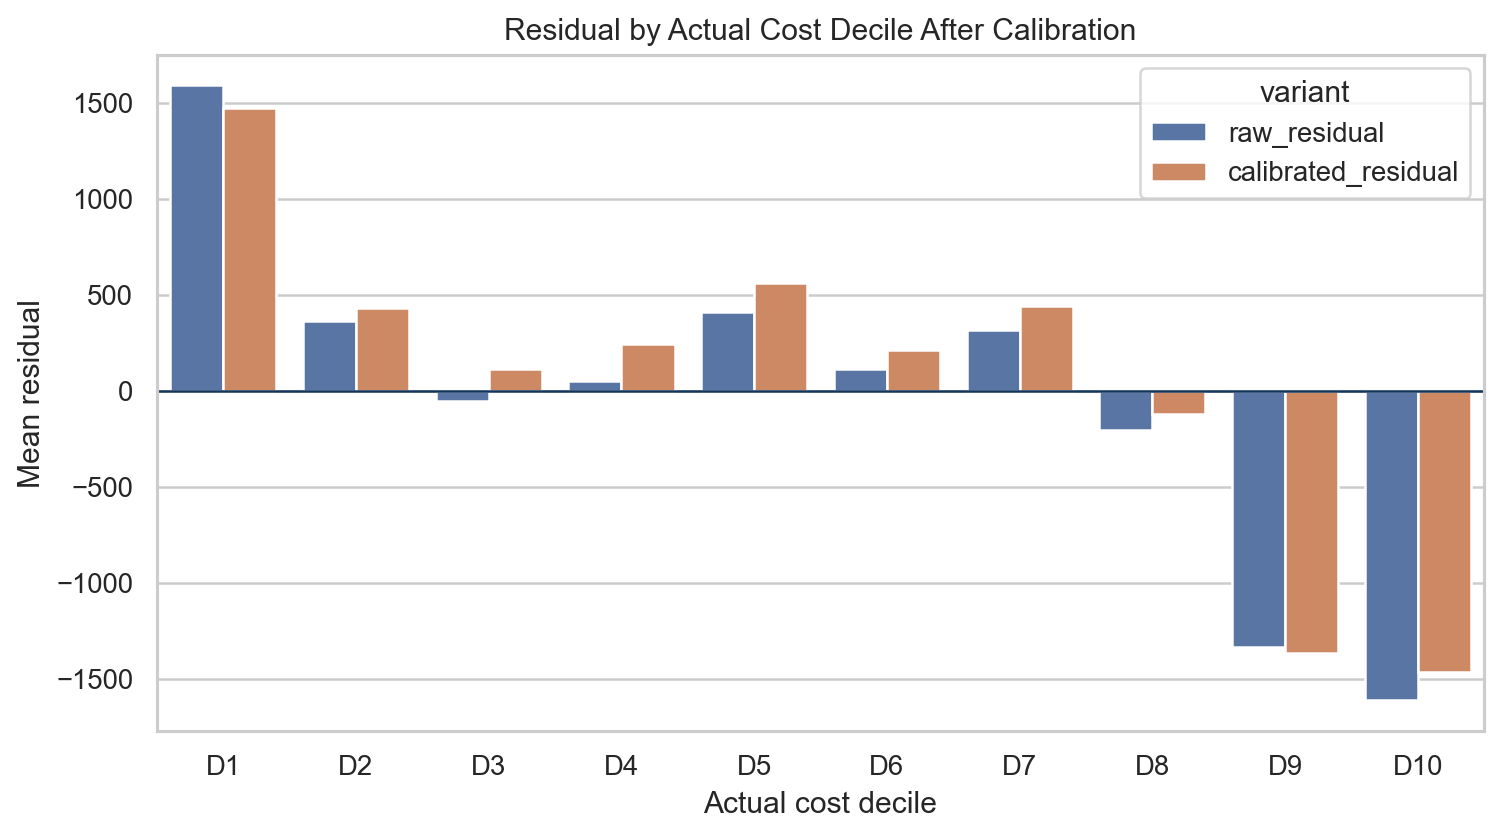

In [11]:
image_path = ROOT / 'outputs/figures/residual_by_cost_decile_after_calibration.png'
display(Markdown("**Residuals by cost decile after calibration**"))
if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print(f"Missing image: {image_path}")

**Technical interpretation:** Calibration improves some percentage or band-style metrics but does not improve MAE/RMSE in the current run.

**Business interpretation:** The Streamlit app therefore treats calibrated cost as secondary diagnostic output unless metadata explicitly chooses it.

**Technical interpretation:** Rounded raw prediction is the default quote-band display because the target is a fixed price grid.

**Business interpretation:** Business users see a valid quote band while analysts can still inspect the raw continuous estimate.

## 9. Ordinal Price-band Challenger

In [12]:
ordinal = pd.read_csv(MODEL_DIR / "ordinal_challenger_metrics.csv")
ordinal

,variant,MAE,RMSE,R2,MAPE,SMAPE,exact_band_accuracy,within_1_band_accuracy,within_2_band_accuracy,within_3_band_accuracy,model
0,hist_gradient_classifier_class,2860.41200,3793.66202,0.92961,12.94497,13.02568,0.1758,0.4284,0.6210,0.7654,HistGradientBoostingClassifier
1,hist_gradient_classifier_expected_value,2514.80348,3211.07163,0.94957,12.14417,11.58309,0.1618,0.4538,0.6818,0.8284,HistGradientBoostingClassifier


**Technical interpretation:** The ordinal/classification challenger tests the target as band labels instead of continuous cost.

**Business interpretation:** The challenger is useful evidence, but the selected regression pipeline remains stronger for the final deployment objective.

## 10. Saved Model Load and Prediction Smoke Test

In [13]:
from insurance_modeling import clean_column_names

model = joblib.load(MODEL_DIR / "final_model.pkl")
raw_df = pd.read_csv(ROOT / "Insurance Data.csv")
sample = clean_column_names(raw_df).drop(columns=["insurance_cost", "applicant_id"], errors="ignore").head(5)
preds = model.predict(sample)
pd.DataFrame({"prediction": preds})

,prediction
0,19133.075218
1,7686.058176
2,29086.553615
3,25242.339615
4,29889.631931


**Technical interpretation:** The saved artifact loads as a fitted sklearn pipeline and predicts finite values for sample rows.

**Business interpretation:** This confirms the deployment file is usable outside the training script.

## 11. Explainability: Permutation Importance

In [14]:
importance = pd.read_csv(MODEL_DIR / "feature_importance.csv")
importance.head(15)

,feature,importance_mean,importance_std
0,weight,16311.43126,172.85174
1,Year_last_admitted,271.82439,11.45123
2,covered_by_any_other_company,136.05852,11.92000
3,regular_checkup_last_year,97.70305,13.13711
4,weight_change_in_last_one_year,39.64431,3.86224
5,years_of_insurance_with_us,31.87428,4.81000
6,exercise,2.44011,0.79075
7,avg_glucose_level,2.18455,1.26426
8,Location,1.33986,0.70960
9,smoking_status,1.14775,0.80525


**Permutation feature importance**

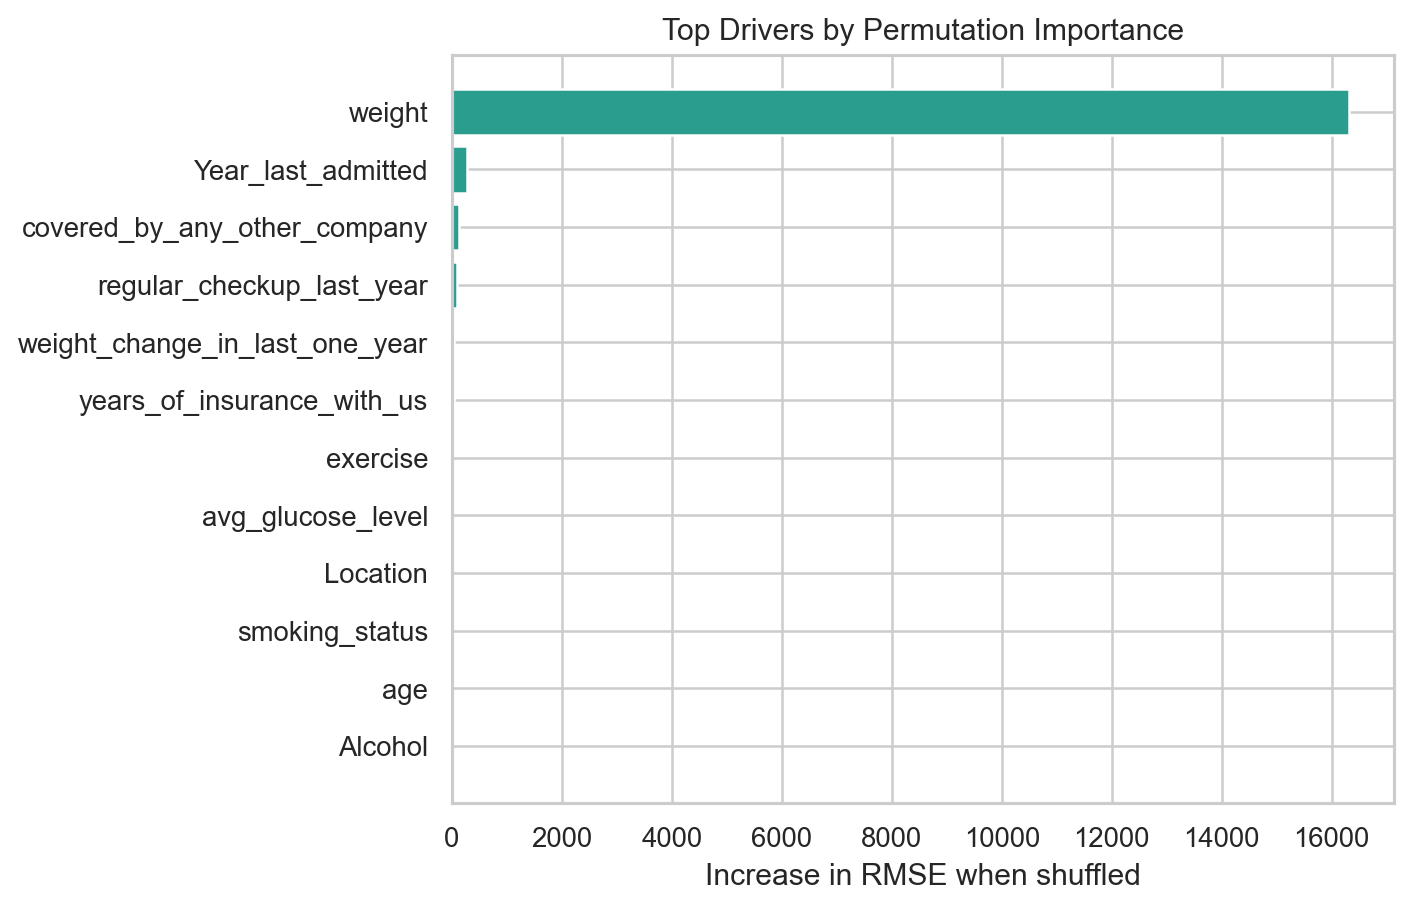

In [15]:
image_path = ROOT / 'outputs/figures/feature_importance.png'
display(Markdown("**Permutation feature importance**"))
if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print(f"Missing image: {image_path}")

**Technical interpretation:** Permutation importance aligns with EDA by highlighting weight and admission/coverage/checkup/weight-change signals.

**Business interpretation:** The explanation is consistent with the Milestone 1 story and avoids introducing a contradictory driver narrative.

## 12. Explainability: SHAP and Partial Dependence

In [16]:
shap_status = json.loads((MODEL_DIR / "shap_status.json").read_text())
display(shap_status)
shap_path = MODEL_DIR / "shap_importance.csv"
if shap_path.exists():
    display(pd.read_csv(shap_path).head(15))

{'available': True,
 'model': 'BaseLightGBMRegressor',
 'status': 'completed',
 'sample_rows': 500,
 'table': 'outputs/models/shap_importance.csv',
 'figure': 'outputs/figures/shap_importance_bar.png'}

,feature,mean_abs_shap
0,weight,11203.692486
1,covered_by_any_other_company_N,537.070685
2,years_since_last_admitted,400.393394
3,regular_checkup_last_year,331.997042
4,years_of_insurance_with_us,188.497309
5,weight_change_in_last_one_year,102.874832
6,was_admitted_before,83.757977
7,daily_avg_steps,48.689754
8,weight_bmi_interaction,47.174617
9,bmi,42.496589


**SHAP importance when available**

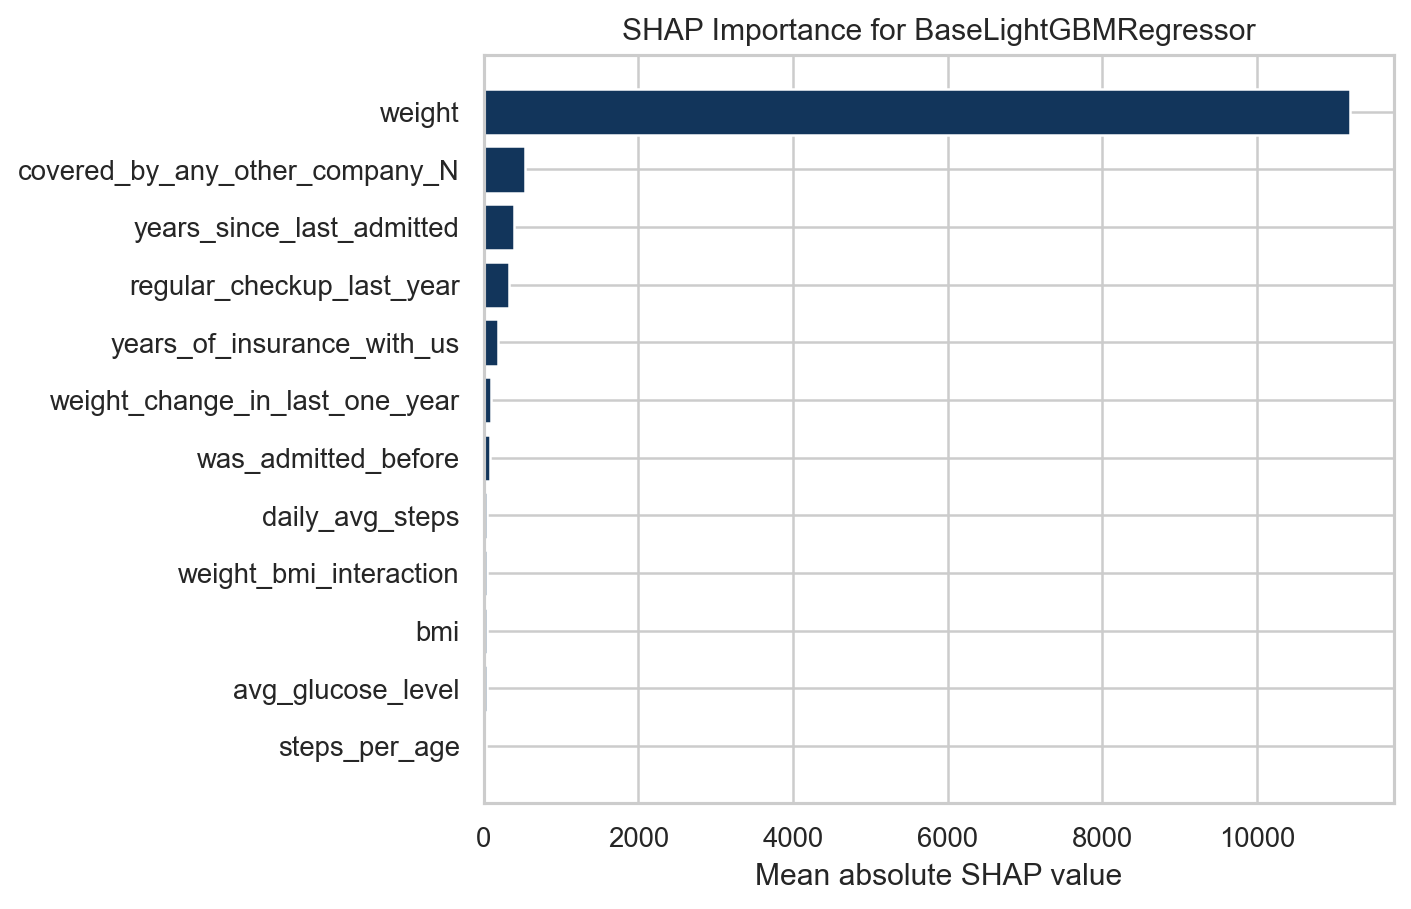

In [17]:
image_path = ROOT / 'outputs/figures/shap_importance_bar.png'
display(Markdown("**SHAP importance when available**"))
if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print(f"Missing image: {image_path}")

**Partial dependence for top features**

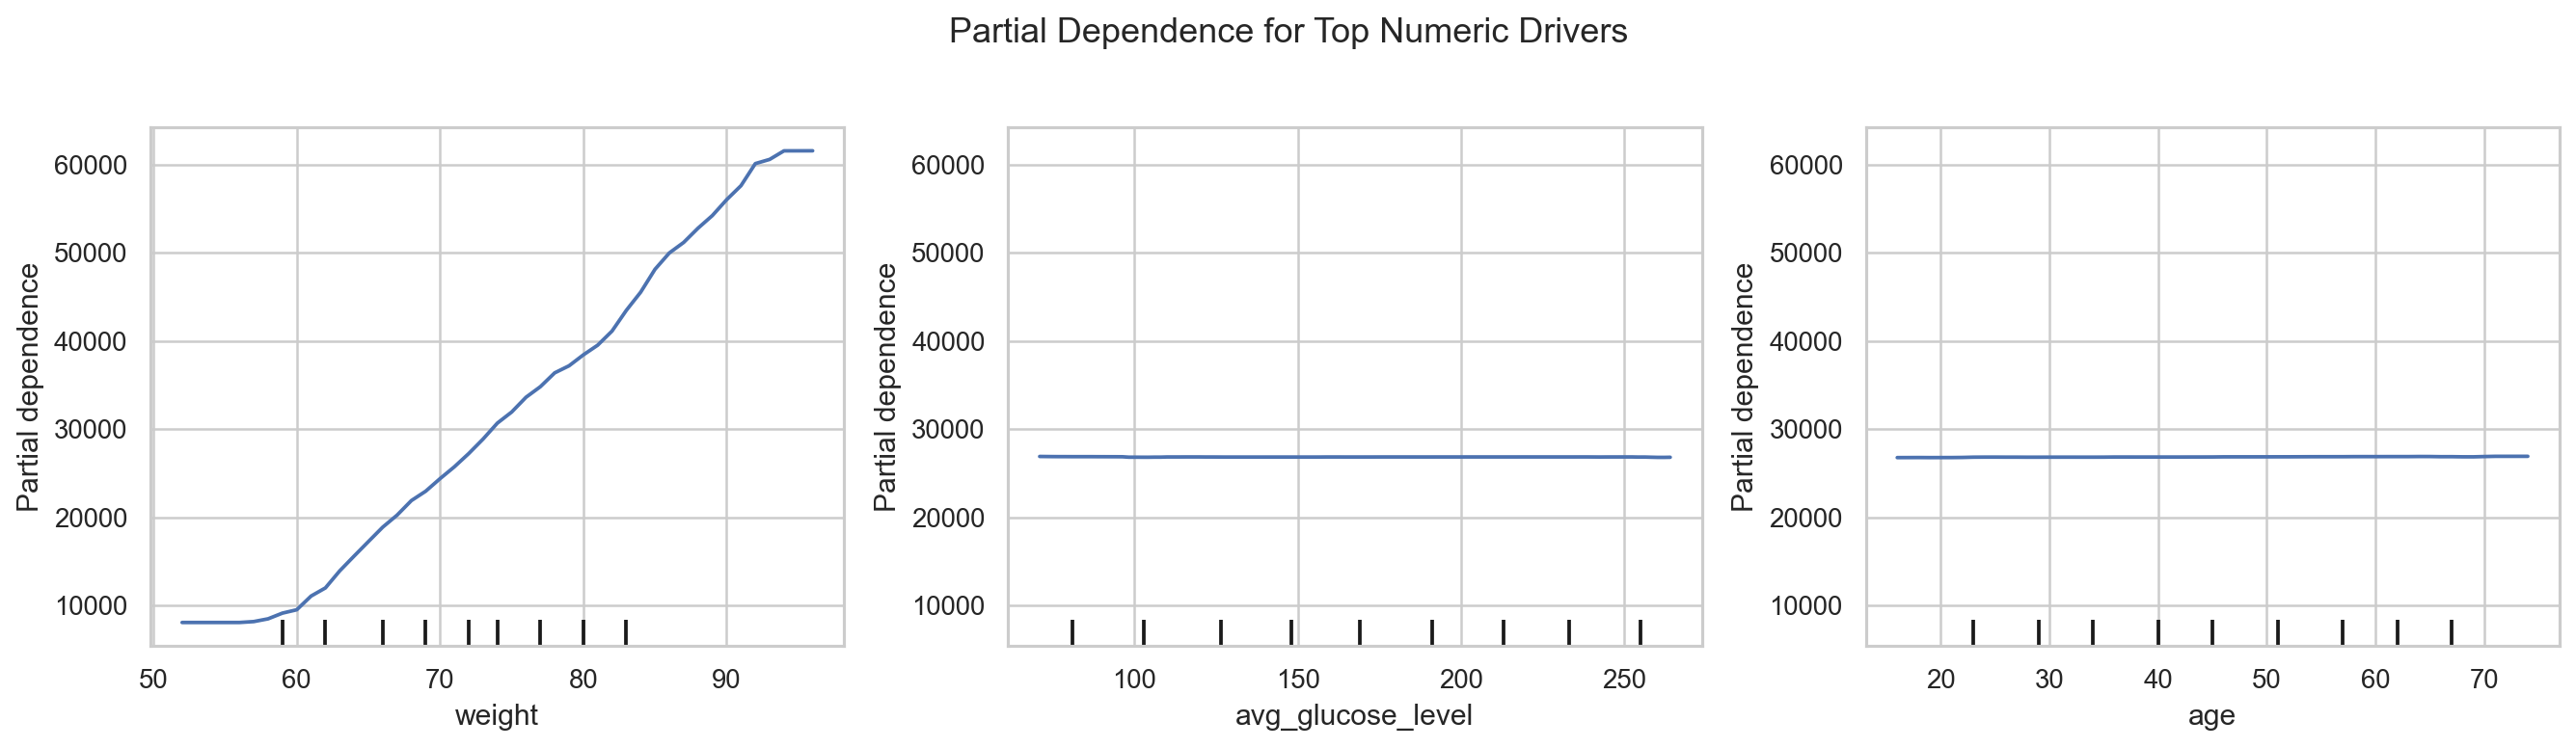

In [18]:
image_path = ROOT / 'outputs/figures/partial_dependence_top_features.png'
display(Markdown("**Partial dependence for top features**"))
if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print(f"Missing image: {image_path}")

**Technical interpretation:** SHAP is generated when the installed environment supports it; permutation importance remains the core deployed explanation.

**Business interpretation:** The package remains robust on machines without SHAP while still including stronger explainability when available.

## 13. Deployment Schema

In [19]:
app_schema = json.loads((MODEL_DIR / "app_schema.json").read_text())
app_schema["numeric_ranges"].keys(), app_schema["target_grid"]["target_unique_count"], app_schema["target_grid"]["target_grid_step"]

(dict_keys(['years_of_insurance_with_us', 'regular_checkup_last_year', 'adventure_sports', 'visited_doctor_last_1_year', 'daily_avg_steps', 'age', 'heart_disease_history', 'other_major_disease_history', 'avg_glucose_level', 'bmi', 'weight', 'weight_change_in_last_one_year', 'fat_percentage', 'Year_last_admitted']),
 54,
 1234)

In [20]:
pd.DataFrame(app_schema["numeric_ranges"]).T

,min,max,median
years_of_insurance_with_us,0.0,8.0,4.0
regular_checkup_last_year,0.0,5.0,0.0
adventure_sports,0.0,1.0,0.0
visited_doctor_last_1_year,0.0,12.0,3.0
daily_avg_steps,2034.0,11255.0,5089.0
age,16.0,74.0,45.0
heart_disease_history,0.0,1.0,0.0
other_major_disease_history,0.0,1.0,0.0
avg_glucose_level,57.0,277.0,168.0
bmi,12.3,100.6,30.5


**Technical interpretation:** The app schema includes training-derived ranges, including Year_last_admitted, and excludes applicant_id.

**Business interpretation:** The Streamlit form stays aligned with model inputs and avoids asking the user for an identifier.

## 14. Streamlit Deployment Logic

In [21]:
deployment_variant = metadata.get("deployment_variant", {})
deployment_variant

{'analytics_prediction': 'raw_continuous',
 'quote_band': 'rounded_to_nearest_price_band',
 'risk_category': 'raw_continuous',
 'calibrated_prediction': 'secondary_diagnostic',
 'reason': 'Calibration is reported because it improves some percentage/band metrics, but raw prediction is retained for MAE/RMSE-oriented analytics and quote-band rounding.'}

**Technical interpretation:** Deployment metadata separates raw analytical estimates, quote-band rounding, optional calibration, and risk category logic.

**Business interpretation:** The app displays calibrated cost as context but defaults quote-band output to the selected raw-rounded business variant.

## 15. Final Metrics for Report Synchronization

In [22]:
selected_mask = metrics["selected_final_model"].astype(str).str.lower().isin(["true", "1"])
selected = metrics.loc[selected_mask].iloc[0]
best_test = metrics.sort_values(["test_RMSE", "test_MAE"]).iloc[0]
pd.DataFrame(
    [
        {"comparison": "selected_final_model", **selected[["model", "test_MAE", "test_RMSE", "test_R2"]].to_dict()},
        {"comparison": "best_test_rmse_model", **best_test[["model", "test_MAE", "test_RMSE", "test_R2"]].to_dict()},
    ]
)

,comparison,model,test_MAE,test_RMSE,test_R2
0,selected_final_model,BaseHistGradientBoostingRegressorAlt,2393.5902,2982.4414,0.9565
1,best_test_rmse_model,HistGradientBoostingRegressor,2381.4487,2971.1530,0.9568


**Technical interpretation:** The selected model and best test-RMSE model are both reported so there is no contradiction across deliverables.

**Business interpretation:** A small RMSE gap is acceptable because the selection reason is parsimony and stability, not pure leaderboard rank.

## 16. Business Recommendations

**Technical interpretation:** Use the model as pricing decision support and keep raw, calibrated, and rounded outputs clearly labeled.

**Business interpretation:** Pricing teams can use the output for triage, but underwriting authority should remain with policy and human review.

**Technical interpretation:** Monitor drift, segment-level error, and fairness-sensitive variables such as Gender and Location after deployment.

**Business interpretation:** A capstone model should not become a production pricing rule without compliance review.

## 17. Reproducibility and Required Artifacts

In [23]:
required = [
    ROOT / "run_all.py",
    ROOT / "insurance_modeling.py",
    ROOT / "app.py",
    MODEL_DIR / "final_model.pkl",
    MODEL_DIR / "model_metrics.csv",
    MODEL_DIR / "final_model_summary.csv",
    MODEL_DIR / "app_schema.json",
]
pd.DataFrame({"artifact": [str(p.relative_to(ROOT)) for p in required], "exists": [p.exists() for p in required]})

,artifact,exists
0,run_all.py,True
1,insurance_modeling.py,True
2,app.py,True
3,outputs\models\final_model.pkl,True
4,outputs\models\model_metrics.csv,True
5,outputs\models\final_model_summary.csv,True
6,outputs\models\app_schema.json,True


**Technical interpretation:** The artifact check verifies that the generated modeling and deployment files are present.

**Business interpretation:** Reviewers can reproduce the package by running `python run_all.py` from the project root after installing requirements.

## 18. Milestone 2 Conclusion

**Technical interpretation:** The final modeling package is synchronized across metrics, metadata, reports, notebooks, PPT, and app deployment logic.

**Business interpretation:** The submission gives a coherent story from EDA to model choice to quote-band-ready deployment.